In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("C:/Users/Ashwini/Downloads/Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df=data[['Pclass','Sex','Age','Fare','Survived']]
df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


The selected feature represent demographic ahd socio-economic factors that may influence survival outcomes.these variables are interpreatble and commmonlyused in fairness analysis studies.

In [8]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Survived      0
dtype: int64

In [10]:
df.loc[:, 'Age']=df['Age'].fillna(df['Age'].median())

In [12]:
df=pd.get_dummies(df, columns=['Sex'],drop_first=True)
df.head()

,Pclass,Age,Fare,Survived,Sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False
2,3,26.0,7.9250,1,False
3,1,35.0,53.1000,1,False
4,3,35.0,8.0500,0,True


In [24]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 4)
(179, 4)
(712,)
(179,)


In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

# Prediction And Evaluation

In [38]:
y_pred=model.predict(x_test)

In [44]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.8044692737430168

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
 [[90 15]
 [20 54]]


The trained logistic regression model was evaluated using accurancy,precision,recall,and confusion matrix,demonstrating sffective classification performance on unseen test data

# Model Interpretation and Fairness Analysis

In [50]:
import pandas as pd 
feature_importance=pd.DataFrame({'Feature':x.columns,'Coefficient':model.coef_[0]})
feature_importance=feature_importance.sort_values(by='Coefficient',ascending=False)
feature_importance

,Feature,Coefficient
2,Fare,0.001183
1,Age,-0.025163
0,Pclass,-0.996326
3,Sex_male,-2.465606


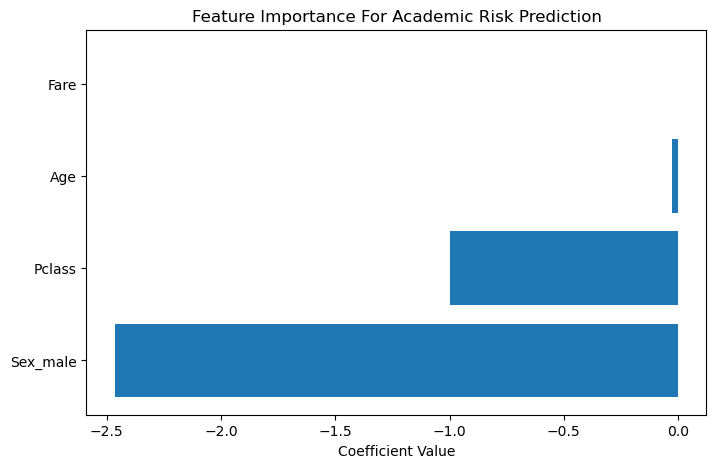

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'],feature_importance['Coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Feature Importance For Academic Risk Prediction")
plt.gca().invert_yaxis()
plt.show()

In [56]:
df['prediction']=model.predict(x)
df.groupby('Sex_male')[['Survived','prediction']].mean()

,Survived,prediction
Sex_male,,
False,0.742038,0.968153
True,0.188908,0.027730
